In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

points={
    'M1': (-2, 3), 'M2': (-2, 1), 'M3': (-2, -1),
    'M4': (2, -1), 'M5': (2, 1), 'M6': (1, 0)
}

X=np.array(list(points.values()))
labels=list(points.keys())

print(X)
print(labels)

[[-2  3]
 [-2  1]
 [-2 -1]
 [ 2 -1]
 [ 2  1]
 [ 1  0]]
['M1', 'M2', 'M3', 'M4', 'M5', 'M6']


In [6]:
initial_centroids=np.array([points['M1'], points['M2']])

kmeans=KMeans(n_clusters=2, init=initial_centroids, n_init=1, random_state=42)
kmeans.fit(X)

clusters=kmeans.labels_
final_centroids=kmeans.cluster_centers_

In [7]:
print("-- Resultats du Clustering--")
for i in range(2):
    cluster_points= [labels[j] for j, cluster_id in enumerate(clusters) if cluster_id == i]
    print(f"Classe {i+1}: {cluster_points}")
    print(f"Centroide final: ({final_centroids[i][0]:.2f}, {final_centroids[i][1]:.2f})")

-- Resultats du Clustering--
Classe 1: ['M1', 'M2']
Centroide final: (-2.00, 2.00)
Classe 2: ['M3', 'M4', 'M5', 'M6']
Centroide final: (0.75, -0.25)


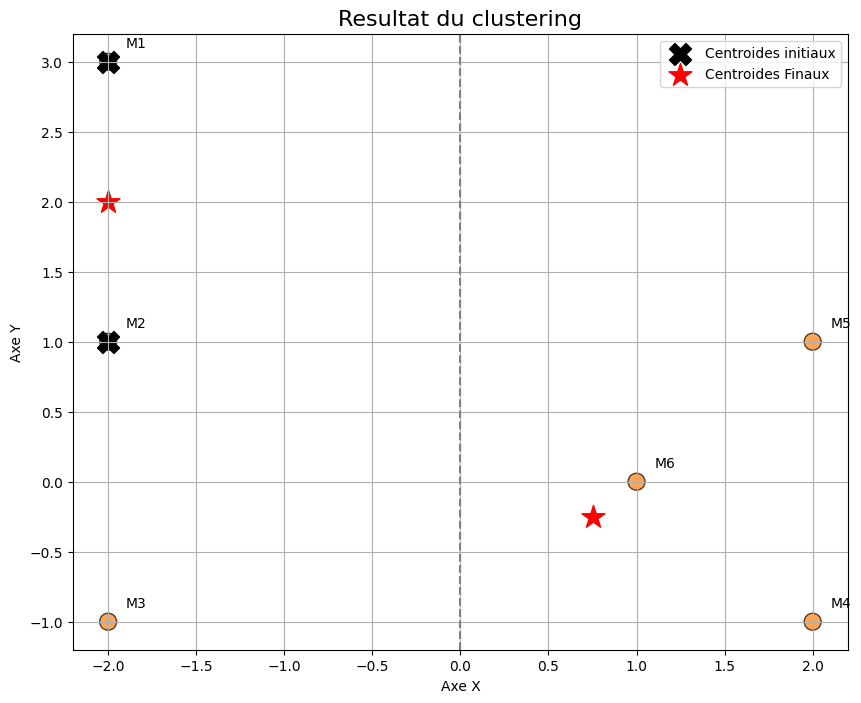

In [8]:
plt.figure(figsize=(10,8))
colors = ['#1f77b4', '#ff7f0e']
cluster_colors=[colors[c] for c in clusters]

plt.scatter(X[:, 0], X[:, 1], c=cluster_colors, s=150, alpha=0.7, edgecolors='k')

for i, label in enumerate(labels):
    plt.annotate(label, (X[i, 0]+0.1, X[i, 1] + 0.1))

plt.scatter(initial_centroids[:, 0], initial_centroids[:, 1], c='black', marker='X', s=250, label='Centroides initiaux')
plt.scatter(final_centroids[:, 0],final_centroids[:, 1], c='red', marker='*', s=300, label='Centroides Finaux')

plt.title('Resultat du clustering', fontsize=16)
plt.xlabel('Axe X')
plt.ylabel('Axe Y')
plt.axvline(x=0, color='gray', linestyle='--')
plt.legend()
plt.grid(True)
plt.show()